In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.monte_carlo import run_simulation

import numpy as np
import matplotlib.pyplot as plt

In [2]:
params = {
    "S0": 2000.0,
    "mu": 0.0,
    "sigma": 0.6,
    "Q": 1.0,
    "B0": 800.0,
    "LT": 0.8,
    "r_b": 0.02,
    "T": 1.0,
    "N": 252,
    "n_paths": 5000,
}

In [3]:
def set_hf0(params, hf0_target):
    p = params.copy()
    Q = p["Q"]
    S0 = p["S0"]
    LT = p["LT"]

    p["B0"] = (Q * S0 * LT) / hf0_target
    return p

In [4]:
hf0_grid = np.linspace(1.1, 2.5, 8)
sigma_levels = [0.2, 0.4, 0.6, 0.8]

results_matrix = {}

for sigma in sigma_levels:
    probs = []

    for hf0 in hf0_grid:
        p = set_hf0(params, hf0)
        p["sigma"] = sigma

        res = run_simulation(p)
        probs.append(res["liquidation_prob"])

    results_matrix[sigma] = probs

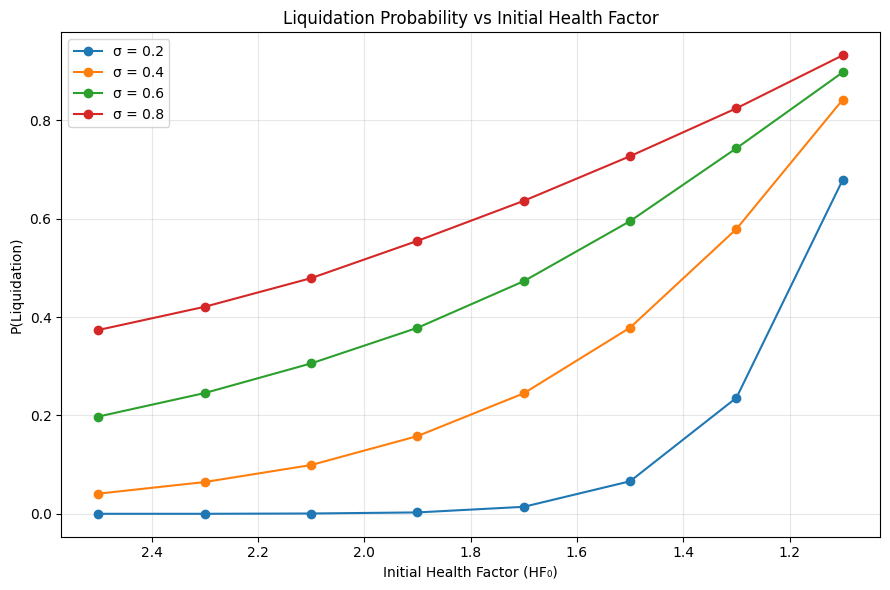

In [5]:
plt.figure(figsize=(9, 6))

for sigma in sigma_levels:
    plt.plot(
        hf0_grid,
        results_matrix[sigma],
        marker="o",
        label=f"σ = {sigma}"
    )

plt.title("Liquidation Probability vs Initial Health Factor")
plt.xlabel("Initial Health Factor (HF₀)")
plt.ylabel("P(Liquidation)")

plt.gca().invert_xaxis()
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

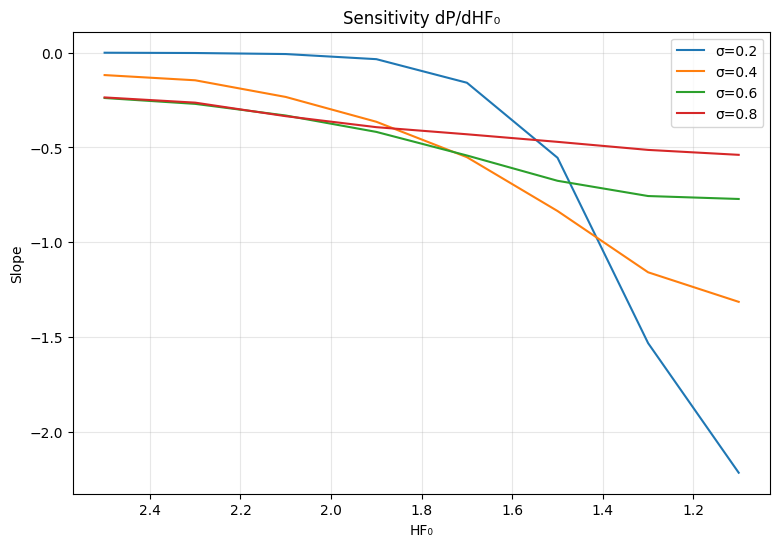

In [6]:
plt.figure(figsize=(9, 6))

for sigma in sigma_levels:
    probs = np.array(results_matrix[sigma])
    slopes = np.gradient(probs, hf0_grid)

    plt.plot(hf0_grid, slopes, label=f"σ={sigma}")

plt.title("Sensitivity dP/dHF₀")
plt.xlabel("HF₀")
plt.ylabel("Slope")

plt.gca().invert_xaxis()
plt.legend()
plt.grid(alpha=0.3)

plt.show()